<a href="https://colab.research.google.com/github/pownz123-glitch/dataact2/blob/main/bajao_activity_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
import os
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

In [ ]:
path = kagglehub.dataset_download("danielcorredera/student-mat-csv")
print("Path to dataset files: ", path)


100%|██████████| 7.85k/7.85k [00:00<00:00, 11.9MB/s]

Extracting files...
Path to dataset files:  /root/.cache/kagglehub/datasets/danielcorredera/student-mat-csv/versions/1


In [ ]:
print(os.listdir(path))

['student-mat.csv']


In [ ]:
file_path = os.path.join(path, "student-mat.csv")
df = pd.read_csv(file_path, sep=';')

In [ ]:
df

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,20,U,LE3,A,2,2,services,services,...,5,5,4,4,5,4,11,9,9,9
391,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,3,14,16,16
392,MS,M,21,R,GT3,T,1,1,other,other,...,5,5,3,3,3,3,3,10,8,7
393,MS,M,18,R,LE3,T,3,2,services,other,...,4,4,1,3,4,5,0,11,12,10


In [ ]:
df.tail()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
390,MS,M,20,U,LE3,A,2,2,services,services,...,5,5,4,4,5,4,11,9,9,9
391,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,3,14,16,16
392,MS,M,21,R,GT3,T,1,1,other,other,...,5,5,3,3,3,3,3,10,8,7
393,MS,M,18,R,LE3,T,3,2,services,other,...,4,4,1,3,4,5,0,11,12,10
394,MS,M,19,U,LE3,T,1,1,other,at_home,...,3,2,3,3,3,5,5,8,9,9


In [ ]:
print("Number of raw; ", df.shape[0])
print("Number of columns: ", df.shape[1])

Number of raw;  395
Number of columns:  33


In [ ]:
print(df.columns)

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')


In [ ]:
df.info

<bound method DataFrame.info of     school sex  age address famsize Pstatus  Medu  Fedu      Mjob      Fjob  \
0       GP   F   18       U     GT3       A     4     4   at_home   teacher   
1       GP   F   17       U     GT3       T     1     1   at_home     other   
2       GP   F   15       U     LE3       T     1     1   at_home     other   
3       GP   F   15       U     GT3       T     4     2    health  services   
4       GP   F   16       U     GT3       T     3     3     other     other   
..     ...  ..  ...     ...     ...     ...   ...   ...       ...       ...   
390     MS   M   20       U     LE3       A     2     2  services  services   
391     MS   M   17       U     LE3       T     3     1  services  services   
392     MS   M   21       R     GT3       T     1     1     other     other   
393     MS   M   18       R     LE3       T     3     2  services     other   
394     MS   M   19       U     LE3       T     1     1     other   at_home   

     ... famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0    ...      4        3      4     1     1      3        6   5   6   6  
1    ...      5        3      3     1     1      3        4   5   5   6  
2    ...      4        3      2     2     3      3       10   7   8  10  
3    ...      3        2      2     1     1      5        2  15  14  15  
4    ...      4        3      2     1     2      5        4   6  10  10  
..   ...    ...      ...    ...   ...   ...    ...      ...  ..  ..  ..  
390  ...      5        5      4     4     5      4       11   9   9   9  
391  ...      2        4      5     3     4      2        3  14  16  16  
392  ...      5        5      3     3     3      3        3  10   8   7  
393  ...      4        4      1     3     4      5        0  11  12  10  
394  ...      3        2      3     3     3      5        5   8   9   9  

[395 rows x 33 columns]>

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 34 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [ ]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [ ]:
print("Average grade; ", df["G3"].min())
print("Average final grade; ", df["G3"].max())

Average grade;  0
Average final grade;  20


In [ ]:
print(df["sex"].value_counts())

sex
F    208
M    187
Name: count, dtype: int64


In [ ]:
print(df["school"].value_counts())

school
GP    349
MS     46
Name: count, dtype: int64


Text(0.5, 1.0, 'Distributio of Final Grades')

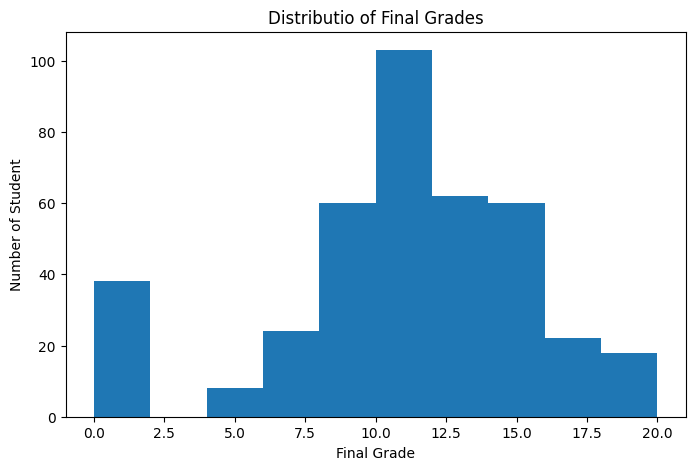

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.hist(df["G3"], bins=10)

plt.xlabel("Final Grade")
plt.ylabel("Number of Student")
plt.title("Distributio of Final Grades")

In [ ]:
df.groupby("studytime")["G3"].mean()

,G3
studytime,
1,10.047619
2,10.171717
3,11.400000
4,11.259259


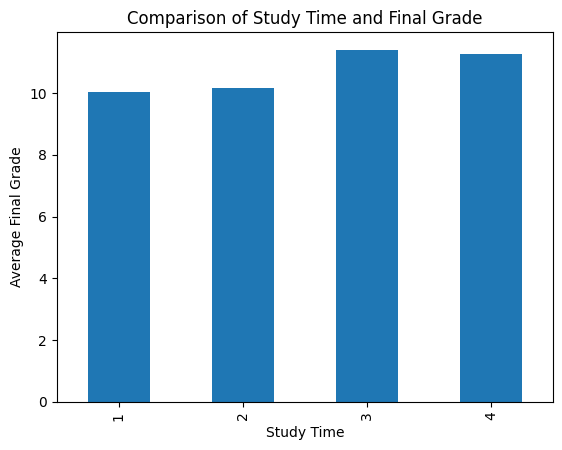

In [ ]:
df.groupby("studytime")["G3"].mean().plot(kind = "bar")

plt.xlabel("Study Time")
plt.ylabel("Average Final Grade")
plt.title("Comparison of Study Time and Final Grade")

plt.show()

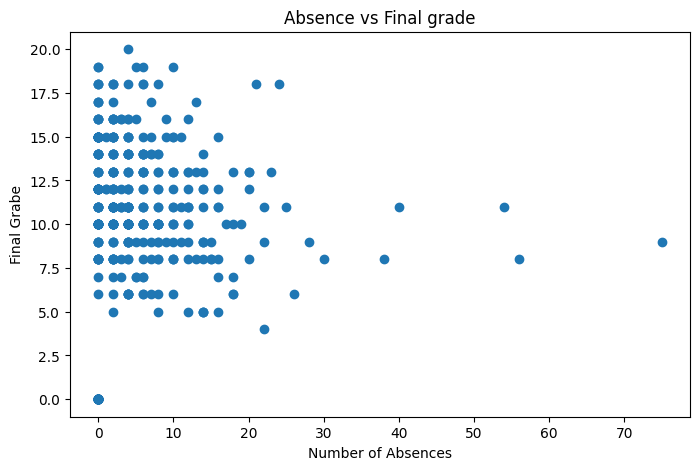

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(df["absences"], df["G3"])

plt.xlabel("Number of Absences")
plt.ylabel("Final Grabe")
plt.title("Absence vs Final grade")

plt.show()


In [ ]:
print(df["absences"].corr(df["G3"]))

0.03424731615006931


In [ ]:
df["pass"] = (df["G3"]>=10).astype(int)

In [ ]:
print(df["pass"].value_counts())

pass
1    265
0    130
Name: count, dtype: int64


In [ ]:
features =[
    "age", "traveltime", "studytime", "failures", "G1", "G2"
]
x =df[features]
y = df["pass"]

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42,
                                                    stratify=y
                                                    )

In [ ]:
model = DecisionTreeClassifier(random_state=42)
model.fit(x_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
y_pred = model.predict(x_test)

print(y_pred)

[1 0 1 1 1 1 1 0 1 1 1 0 1 1 0 1 0 0 0 0 0 1 0 1 1 1 1 1 0 0 0 0 1 1 1 0 0
 0 1 0 0 0 1 1 1 1 1 1 1 1 0 1 1 0 1 0 0 0 0 1 1 0 0 1 1 1 1 1 0 1 0 1 1 0
 0 1 0 1 1]


In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: ", accuracy)

Accuracy:  0.8607594936708861


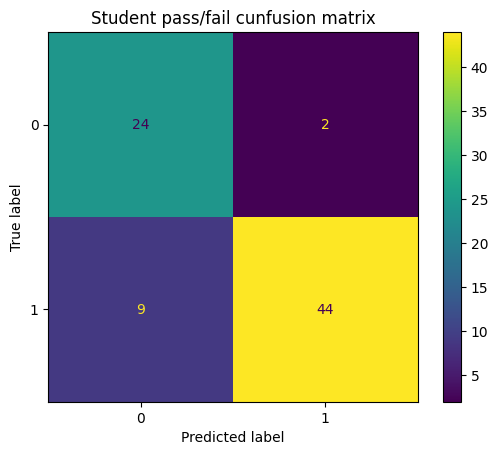

In [ ]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Student pass/fail cunfusion matrix")
plt.show()

Prediction Result table


In [ ]:
results = x_test.copy()

results["Actual"] = y_test
results["Prediction"] = y_pred

results.head(10)


,age,traveltime,studytime,failures,G1,G2,Actual,Prediction
305,18,1,2,1,14,12,1,1
225,18,1,2,1,9,8,0,0
237,16,1,1,0,13,12,1,1
318,17,1,3,0,11,11,1,1
182,17,1,2,0,16,17,1,1
94,15,1,4,0,11,13,1,1
34,16,1,1,0,12,14,1,1
307,19,2,1,1,8,9,0,0
33,15,1,2,0,8,10,1,1
36,15,1,3,0,15,16,1,1


In [ ]:
results["Risk"] =results["Prediction"].map({
    0: "at Risk",
    1: "likely to pass"
})

results.head(10)

,age,traveltime,studytime,failures,G1,G2,Actual,Prediction,Risk
305,18,1,2,1,14,12,1,1,likely to pass
225,18,1,2,1,9,8,0,0,at Risk
237,16,1,1,0,13,12,1,1,likely to pass
318,17,1,3,0,11,11,1,1,likely to pass
182,17,1,2,0,16,17,1,1,likely to pass
94,15,1,4,0,11,13,1,1,likely to pass
34,16,1,1,0,12,14,1,1,likely to pass
307,19,2,1,1,8,9,0,0,at Risk
33,15,1,2,0,8,10,1,1,likely to pass
36,15,1,3,0,15,16,1,1,likely to pass


In [ ]:
results["Recommendation"] = results["Prediction"].map({
    0: "Prioritize for academic intervention",
    1: "Continue regular monitoring"

})
results.head(10)

,age,traveltime,studytime,failures,G1,G2,Actual,Prediction,Risk,Recommendation
305,18,1,2,1,14,12,1,1,likely to pass,Continue regular monitoring
225,18,1,2,1,9,8,0,0,at Risk,Prioritize for academic intervention
237,16,1,1,0,13,12,1,1,likely to pass,Continue regular monitoring
318,17,1,3,0,11,11,1,1,likely to pass,Continue regular monitoring
182,17,1,2,0,16,17,1,1,likely to pass,Continue regular monitoring
94,15,1,4,0,11,13,1,1,likely to pass,Continue regular monitoring
34,16,1,1,0,12,14,1,1,likely to pass,Continue regular monitoring
307,19,2,1,1,8,9,0,0,at Risk,Prioritize for academic intervention
33,15,1,2,0,8,10,1,1,likely to pass,Continue regular monitoring
36,15,1,3,0,15,16,1,1,likely to pass,Continue regular monitoring


In [ ]:
probabilities = model.predict_proba(x_test)[:, 1]
results["Probability_of_failing"] = 1 - probabilities
results.sort_values(
    "Probability_of_failing",
    ascending=False
).head(20)

,age,traveltime,studytime,failures,G1,G2,Actual,Prediction,Risk,Recommendation,Probability_of_failing
225,18,1,2,1,9,8,0,0,at Risk,Prioritize for academic intervention,1.0
67,16,1,4,0,7,7,0,0,at Risk,Prioritize for academic intervention,1.0
307,19,2,1,1,8,9,0,0,at Risk,Prioritize for academic intervention,1.0
255,17,2,1,1,7,9,0,0,at Risk,Prioritize for academic intervention,1.0
248,18,1,2,1,3,5,0,0,at Risk,Prioritize for academic intervention,1.0
281,17,1,1,1,11,9,1,0,at Risk,Prioritize for academic intervention,1.0
332,18,1,2,0,7,0,0,0,at Risk,Prioritize for academic intervention,1.0
370,19,2,2,2,7,7,0,0,at Risk,Prioritize for academic intervention,1.0
208,16,2,1,0,9,9,1,0,at Risk,Prioritize for academic intervention,1.0
7,17,2,2,0,6,5,0,0,at Risk,Prioritize for academic intervention,1.0


In [ ]:
priority_student=results.sort_values(
    "Probability_of_failing",
    ascending=False
).head(20)

priority_student

,age,traveltime,studytime,failures,G1,G2,Actual,Prediction,Risk,Recommendation,Probability_of_failing
225,18,1,2,1,9,8,0,0,at Risk,Prioritize for academic intervention,1.0
67,16,1,4,0,7,7,0,0,at Risk,Prioritize for academic intervention,1.0
307,19,2,1,1,8,9,0,0,at Risk,Prioritize for academic intervention,1.0
255,17,2,1,1,7,9,0,0,at Risk,Prioritize for academic intervention,1.0
248,18,1,2,1,3,5,0,0,at Risk,Prioritize for academic intervention,1.0
281,17,1,1,1,11,9,1,0,at Risk,Prioritize for academic intervention,1.0
332,18,1,2,0,7,0,0,0,at Risk,Prioritize for academic intervention,1.0
370,19,2,2,2,7,7,0,0,at Risk,Prioritize for academic intervention,1.0
208,16,2,1,0,9,9,1,0,at Risk,Prioritize for academic intervention,1.0
7,17,2,2,0,6,5,0,0,at Risk,Prioritize for academic intervention,1.0
